# Introdução à solução de PDEs com `py-pde`

Neste notebook, vamos dar uma primeira passada pela biblioteca `py-pde`.

A ideia é seguir um fluxo bem parecido com o que fizemos nas aulas de ODE:

* definir um problema com solução analítica conhecida;
* construir a malha e os campos discretos;
* resolver o problema estacionário;
* fazer análise de convergência;
* resolver uma versão transiente do mesmo problema;
* comparar algumas opções de solvers;
* terminar com um bônus: resolver Lotka-Volterra usando a infraestrutura da `py-pde`.

Mesmo em problemas simples, vamos definir o modelo usando uma classe customizada. Isso parece um pouco mais trabalhoso no começo, mas cria um padrão que será útil quando os modelos tiverem vários campos, coeficientes heterogêneos ou termos não lineares.

## Importando as dependências

Usaremos `numpy`, `pandas`, `matplotlib`, `scipy` e a `py-pde`. A biblioteca `py-pde` trabalha com três ideias centrais:

* uma **grade**, que descreve a geometria discreta;
* um **campo**, que guarda valores nessa grade;
* uma **PDE**, que define como o campo evolui ou como operadores diferenciais são aplicados.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pde
from pde.solvers import ExplicitSolver, ImplicitSolver, ScipySolver

plt.rcParams.update(
    {
        "axes.grid": True,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "figure.figsize": (8, 4.5),
        "font.size": 11,
    }
)

## Problema-modelo: Poisson 1D estacionário

Vamos começar com

$$
\frac{d^2u}{dx^2}=f(x),
\qquad x\in(0,1),
$$

com condições de contorno de Dirichlet homogêneas:

$$
u(0)=0,
\qquad
u(1)=0.
$$

Escolhemos uma solução analítica conhecida,

$$
u_{\mathrm{exata}}(x)=\sin(\pi x).
$$

Portanto,

$$
f(x)=u_{\mathrm{exata}}''(x)
=
-\pi^2\sin(\pi x).
$$

Assim, conseguimos medir diretamente o erro da solução numérica.

In [2]:
class Poisson1D(pde.PDEBase):
    def __init__(self, boundary_condition=None):
        super().__init__()
        self.boundary_condition = (
            {"value": 0} if boundary_condition is None else boundary_condition
        )

    def exact_stationary(self, positions):
        return np.sin(np.pi * positions)

    def exact_transient(self, positions, final_time):
        return (1.0 - np.exp(-(np.pi**2) * final_time)) * np.sin(np.pi * positions)

    def source(self, positions):
        return -(np.pi**2) * np.sin(np.pi * positions)

    def source_field(self, grid):
        positions = grid.axes_coords[0]
        return pde.ScalarField(grid, data=self.source(positions), label="f(x)")

    def solve_stationary(self, grid):
        return pde.solve_poisson_equation(
            self.source_field(grid),
            bc=self.boundary_condition,
            label="u numérico",
        )

    def evolution_rate(self, state, time=0):
        return state.laplace(self.boundary_condition) - self.source_field(state.grid)


poisson_1d = Poisson1D()

A classe acima concentra as informações do problema:

* solução analítica;
* termo fonte;
* condição de contorno;
* solução estacionária;
* lado direito da versão transiente.

Na `py-pde`, o método `evolution_rate` define a equação transiente

$$
\frac{\partial u}{\partial t}
=
\frac{\partial^2 u}{\partial x^2}-f(x).
$$

Como o estado estacionário satisfaz $u_{xx}=f$, essa dinâmica converge para a solução de Poisson.

## Grade, campo e solução estacionária

Vamos criar uma grade cartesiana em $[0,1]$ com 64 células. A `py-pde` usa campos definidos nos centros das células. Portanto, os pontos de avaliação ficam levemente afastados das fronteiras.

In [3]:
grid_1d = pde.CartesianGrid([[0.0, 1.0]], 64, periodic=False)
positions_1d = grid_1d.axes_coords[0]

source_1d = poisson_1d.source_field(grid_1d)
solution_1d = poisson_1d.solve_stationary(grid_1d)
exact_1d = poisson_1d.exact_stationary(positions_1d)

pd.DataFrame(
    {
        "quantidade": ["número de células", "h", "erro máximo"],
        "valor": [
            grid_1d.shape[0],
            float(grid_1d.discretization[0]),
            float(np.max(np.abs(solution_1d.data - exact_1d))),
        ],
    }
)

,quantidade,valor
0,número de células,64.000000
1,h,0.015625
2,erro máximo,0.000201


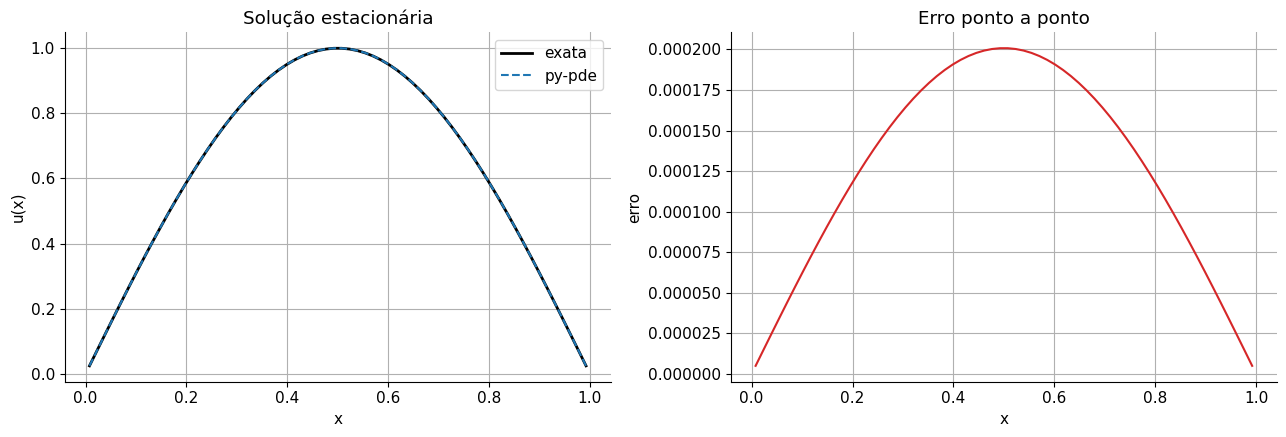

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(positions_1d, exact_1d, color="black", linewidth=2.0, label="exata")
axes[0].plot(positions_1d, solution_1d.data, "--", label="py-pde")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].set_title("Solução estacionária")
axes[0].legend()

axes[1].plot(positions_1d, np.abs(solution_1d.data - exact_1d), color="tab:red")
axes[1].set_xlabel("x")
axes[1].set_ylabel("erro")
axes[1].set_title("Erro ponto a ponto")

fig.tight_layout()
plt.show()

O erro é pequeno e tem a forma esperada para uma aproximação por diferenças finitas de segunda ordem. Como a solução é suave, a discretização espacial deve dominar o erro.

## Convergência espacial

Agora repetimos o cálculo para várias malhas. Para cada malha, calculamos

$$
\|e_h\|_\infty=\max_i |u_i-u_{\mathrm{exata}}(x_i)|
$$

e também uma norma discreta do tipo $L^2$,

$$
\|e_h\|_{2,h}
=
\left(h\sum_i |u_i-u_{\mathrm{exata}}(x_i)|^2\right)^{1/2}.
$$

Para este problema, esperamos ordem aproximadamente 2 em ambas as normas.

In [5]:
def estimate_orders(step_sizes, errors):
    step_sizes = np.asarray(step_sizes, dtype=float)
    errors = np.asarray(errors, dtype=float)
    return np.log(errors[:-1] / errors[1:]) / np.log(step_sizes[:-1] / step_sizes[1:])


def convergence_triangle(ax, base_x, base_y, order, width_factor=1.8, color="0.25"):
    left_x = base_x / width_factor
    right_x = base_x
    lower_y = base_y
    upper_y = base_y * width_factor**order

    ax.plot([left_x, right_x], [lower_y, lower_y], color=color, linewidth=1.2)
    ax.plot([right_x, right_x], [lower_y, upper_y], color=color, linewidth=1.2)
    ax.plot([left_x, right_x], [lower_y, upper_y], color=color, linewidth=1.2)
    ax.text(
        np.sqrt(left_x * right_x),
        upper_y * 1.08,
        rf"$O(h^{order:g})$",
        ha="center",
        va="bottom",
        color=color,
    )


mesh_sizes_1d = [16, 32, 64, 128, 256]
stationary_rows_1d = []

for num_cells in mesh_sizes_1d:
    grid = pde.CartesianGrid([[0.0, 1.0]], num_cells, periodic=False)
    positions = grid.axes_coords[0]
    numerical = poisson_1d.solve_stationary(grid).data
    exact = poisson_1d.exact_stationary(positions)
    error = numerical - exact
    step_size = float(grid.discretization[0])

    stationary_rows_1d.append(
        {
            "N": num_cells,
            "h": step_size,
            "erro máximo": np.max(np.abs(error)),
            "erro L2 discreto": np.sqrt(step_size * np.sum(error**2)),
        }
    )

stationary_convergence_1d = pd.DataFrame(stationary_rows_1d)
stationary_convergence_1d

,N,h,erro máximo,erro L2 discreto
0,16,0.062500,0.003203,0.002276
1,32,0.031250,0.000803,0.000568
2,64,0.015625,0.000201,0.000142
3,128,0.007812,0.000050,0.000035
4,256,0.003906,0.000013,0.000009


In [6]:
orders_max_1d = estimate_orders(
    stationary_convergence_1d["h"],
    stationary_convergence_1d["erro máximo"],
)
orders_l2_1d = estimate_orders(
    stationary_convergence_1d["h"],
    stationary_convergence_1d["erro L2 discreto"],
)

pd.DataFrame(
    {
        "N fino": stationary_convergence_1d["N"].iloc[1:].to_numpy(),
        "ordem pelo erro máximo": orders_max_1d,
        "ordem pelo erro L2": orders_l2_1d,
    }
)

,N fino,ordem pelo erro máximo,ordem pelo erro L2
0,32,1.996862,2.002087
1,64,1.999217,2.000522
2,128,1.999804,2.000130
3,256,1.999951,2.000033


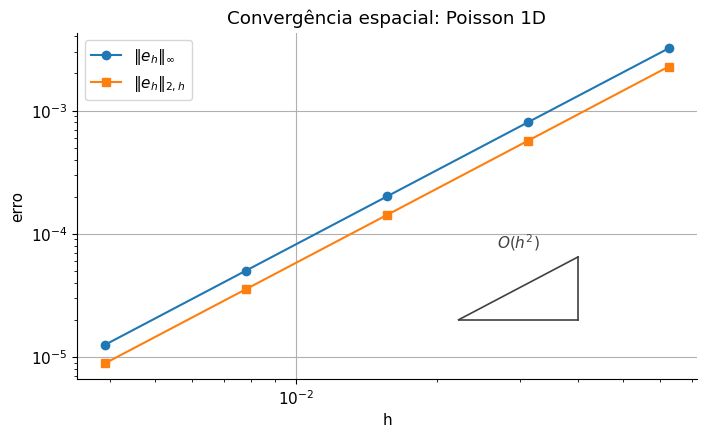

In [7]:
fig, ax = plt.subplots()

ax.loglog(
    stationary_convergence_1d["h"],
    stationary_convergence_1d["erro máximo"],
    "o-",
    label=r"$\|e_h\|_\infty$",
)
ax.loglog(
    stationary_convergence_1d["h"],
    stationary_convergence_1d["erro L2 discreto"],
    "s-",
    label=r"$\|e_h\|_{2,h}$",
)
convergence_triangle(ax, base_x=0.04, base_y=2e-5, order=2)

ax.set_xlabel("h")
ax.set_ylabel("erro")
ax.set_title("Convergência espacial: Poisson 1D")
ax.legend()
plt.show()

A taxa observada fica muito próxima de 2. Isso é compatível com o operador Laplaciano discreto de segunda ordem usado na malha cartesiana.

## Versão transiente: relaxação até o estado estacionário

Agora resolvemos

$$
\frac{\partial u}{\partial t}
=
\frac{\partial^2 u}{\partial x^2}+\pi^2\sin(\pi x),
\qquad
u(x,0)=0.
$$

Como $f(x)=-\pi^2\sin(\pi x)$, essa equação é exatamente

$$
u_t=u_{xx}-f(x).
$$

A solução analítica é

$$
u(x,t)=\left(1-e^{-\pi^2t}\right)\sin(\pi x).
$$

O estado estacionário é recuperado quando $t\to\infty$.

In [8]:
transient_grid_1d = pde.CartesianGrid([[0.0, 1.0]], 64, periodic=False)
transient_positions_1d = transient_grid_1d.axes_coords[0]
initial_1d = pde.ScalarField(
    transient_grid_1d,
    data=np.zeros_like(transient_positions_1d),
    label="u(x,t)",
)

transient_storage_1d = pde.MemoryStorage()
transient_solver_1d = ScipySolver(
    poisson_1d,
    backend="numpy",
    method="BDF",
    rtol=1e-7,
    atol=1e-9,
)
transient_controller_1d = pde.Controller(
    transient_solver_1d,
    t_range=0.5,
    tracker=transient_storage_1d.tracker(0.05),
)
transient_final_1d = transient_controller_1d.run(initial_1d, dt=1e-3)

transient_times_1d = np.array(list(transient_storage_1d.times))
transient_data_1d = np.array([field.data for _, field in transient_storage_1d.items()])

transient_controller_1d.diagnostics["solver"]

{'class': 'ScipySolver',
 'pde_class': 'Poisson1D',
 'dt': 0.001,
 'steps': 483,
 'stochastic': False,
 'backend': 'numpy'}

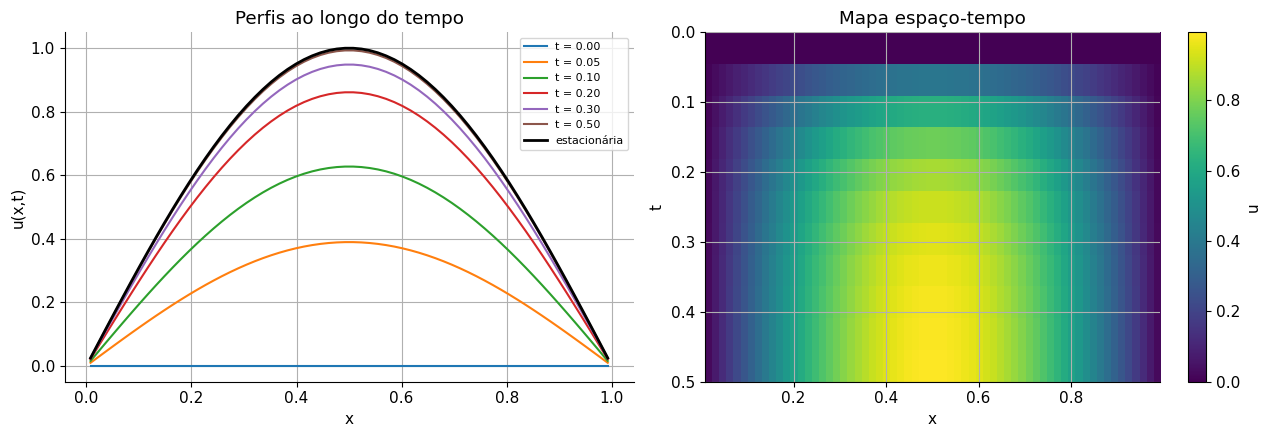

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for storage_index in [0, 1, 2, 4, 6, -1]:
    current_time = transient_times_1d[storage_index]
    axes[0].plot(
        transient_positions_1d,
        transient_data_1d[storage_index],
        label=f"t = {current_time:.2f}",
    )

axes[0].plot(
    transient_positions_1d,
    poisson_1d.exact_stationary(transient_positions_1d),
    color="black",
    linewidth=2.0,
    label="estacionária",
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x,t)")
axes[0].set_title("Perfis ao longo do tempo")
axes[0].legend(fontsize=8)

image = axes[1].imshow(
    transient_data_1d,
    extent=[
        transient_positions_1d[0],
        transient_positions_1d[-1],
        transient_times_1d[-1],
        transient_times_1d[0],
    ],
    aspect="auto",
    cmap="viridis",
)
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
axes[1].set_title("Mapa espaço-tempo")
fig.colorbar(image, ax=axes[1], label="u")

fig.tight_layout()
plt.show()

O primeiro gráfico mostra perfis em instantes diferentes. O segundo é um mapa espaço-tempo: o eixo horizontal é a posição, o eixo vertical é o tempo, e a cor representa o valor de $u(x,t)$.

Esse tipo de visualização é muito útil em problemas transientes, pois permite ver a evolução completa do campo sem precisar mostrar dezenas de curvas separadas.

## Convergência da solução transiente

Para a versão transiente, podemos repetir a análise de convergência em um tempo final fixo. Aqui usamos um solver temporal adaptativo com tolerâncias pequenas para que o erro espacial seja dominante.

In [10]:
transient_convergence_rows_1d = []
final_time_1d = 0.2

for num_cells in [16, 32, 64, 128]:
    grid = pde.CartesianGrid([[0.0, 1.0]], num_cells, periodic=False)
    positions = grid.axes_coords[0]
    initial_state = pde.ScalarField(grid, data=np.zeros_like(positions))

    solver = ScipySolver(
        poisson_1d,
        backend="numpy",
        method="Radau",
        rtol=1e-8,
        atol=1e-10,
    )
    controller = pde.Controller(solver, t_range=final_time_1d, tracker=None)
    numerical = controller.run(initial_state, dt=1e-3).data
    exact = poisson_1d.exact_transient(positions, final_time_1d)
    error = numerical - exact
    step_size = float(grid.discretization[0])

    transient_convergence_rows_1d.append(
        {
            "N": num_cells,
            "h": step_size,
            "erro máximo": np.max(np.abs(error)),
            "erro L2 discreto": np.sqrt(step_size * np.sum(error**2)),
        }
    )

transient_convergence_1d = pd.DataFrame(transient_convergence_rows_1d)
transient_convergence_1d

,N,h,erro máximo,erro L2 discreto
0,16,0.062500,0.001877,0.001334
1,32,0.031250,0.000471,0.000333
2,64,0.015625,0.000118,0.000083
3,128,0.007812,0.000029,0.000021


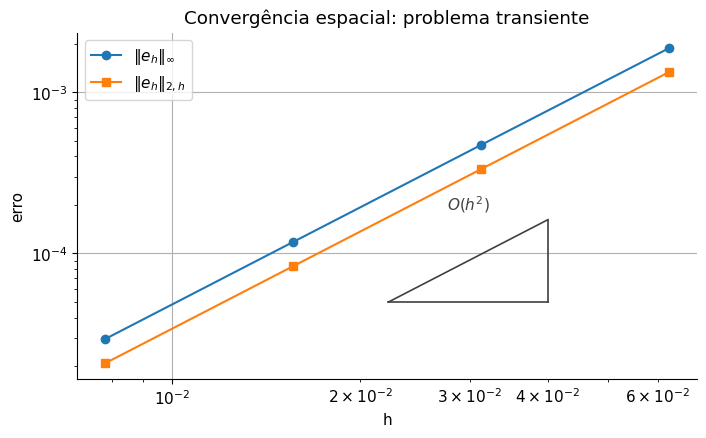

In [11]:
fig, ax = plt.subplots()

ax.loglog(
    transient_convergence_1d["h"],
    transient_convergence_1d["erro máximo"],
    "o-",
    label=r"$\|e_h\|_\infty$",
)
ax.loglog(
    transient_convergence_1d["h"],
    transient_convergence_1d["erro L2 discreto"],
    "s-",
    label=r"$\|e_h\|_{2,h}$",
)
convergence_triangle(ax, base_x=0.04, base_y=5e-5, order=2)

ax.set_xlabel("h")
ax.set_ylabel("erro")
ax.set_title("Convergência espacial: problema transiente")
ax.legend()
plt.show()

Novamente, a taxa observada é aproximadamente de segunda ordem. Isso indica que, para as tolerâncias escolhidas, a discretização espacial continua sendo a principal fonte de erro.

## Comparando solvers temporais

A `py-pde` permite usar diferentes solvers temporais. A comparação abaixo segue a mesma ideia dos exemplos de comparação de solvers da documentação: resolvemos o mesmo problema com vários métodos e coletamos erro, número de passos e tempo de execução.

Aqui estamos comparando a versão transiente do problema até $T=0.2$.

In [12]:
def run_transient_solver_1d(label, solver, time_step, num_cells=32, final_time=0.2):
    grid = pde.CartesianGrid([[0.0, 1.0]], num_cells, periodic=False)
    positions = grid.axes_coords[0]
    initial_state = pde.ScalarField(grid, data=np.zeros_like(positions))

    tic = perf_counter()
    controller = pde.Controller(solver, t_range=final_time, tracker=None)
    solution = controller.run(initial_state, dt=time_step)
    elapsed_ms = 1e3 * (perf_counter() - tic)

    exact = poisson_1d.exact_transient(positions, final_time)
    error = np.max(np.abs(solution.data - exact))
    solver_info = controller.diagnostics["solver"]

    return {
        "método": label,
        "dt usado": time_step,
        "erro máximo": error,
        "tempo (ms)": elapsed_ms,
        "passos": solver_info.get("steps", np.nan),
        "classe": solver_info.get("class", ""),
    }


solver_comparison_rows_1d = [
    run_transient_solver_1d(
        "Euler explícito",
        ExplicitSolver(poisson_1d, scheme="euler", backend="numpy"),
        1e-4,
    ),
    run_transient_solver_1d(
        "Runge-Kutta explícito",
        ExplicitSolver(poisson_1d, scheme="runge-kutta", backend="numpy"),
        1e-4,
    ),
    run_transient_solver_1d(
        "Euler implícito",
        ImplicitSolver(poisson_1d, backend="numpy", maxiter=200, maxerror=1e-8),
        2e-4,
    ),
    run_transient_solver_1d(
        "SciPy RK45",
        ScipySolver(poisson_1d, backend="numpy", method="RK45", rtol=1e-6, atol=1e-8),
        1e-3,
    ),
    run_transient_solver_1d(
        "SciPy BDF",
        ScipySolver(poisson_1d, backend="numpy", method="BDF", rtol=1e-6, atol=1e-8),
        1e-3,
    ),
    run_transient_solver_1d(
        "SciPy Radau",
        ScipySolver(poisson_1d, backend="numpy", method="Radau", rtol=1e-6, atol=1e-8),
        1e-3,
    ),
]

solver_comparison_1d = pd.DataFrame(solver_comparison_rows_1d)
solver_comparison_1d

,método,dt usado,erro máximo,tempo (ms),passos,classe
0,Euler explícito,0.0001,0.000606,560.896542,2000,ExplicitSolver
1,Runge-Kutta explícito,0.0001,0.000471,1928.772980,2000,ExplicitSolver
2,Euler implícito,0.0002,0.000200,899.769282,1000,ImplicitSolver
3,SciPy RK45,0.0010,0.000471,523.219515,1633,ScipySolver
4,SciPy BDF,0.0010,0.000470,118.855065,88,ScipySolver
5,SciPy Radau,0.0010,0.000471,137.448563,158,ScipySolver


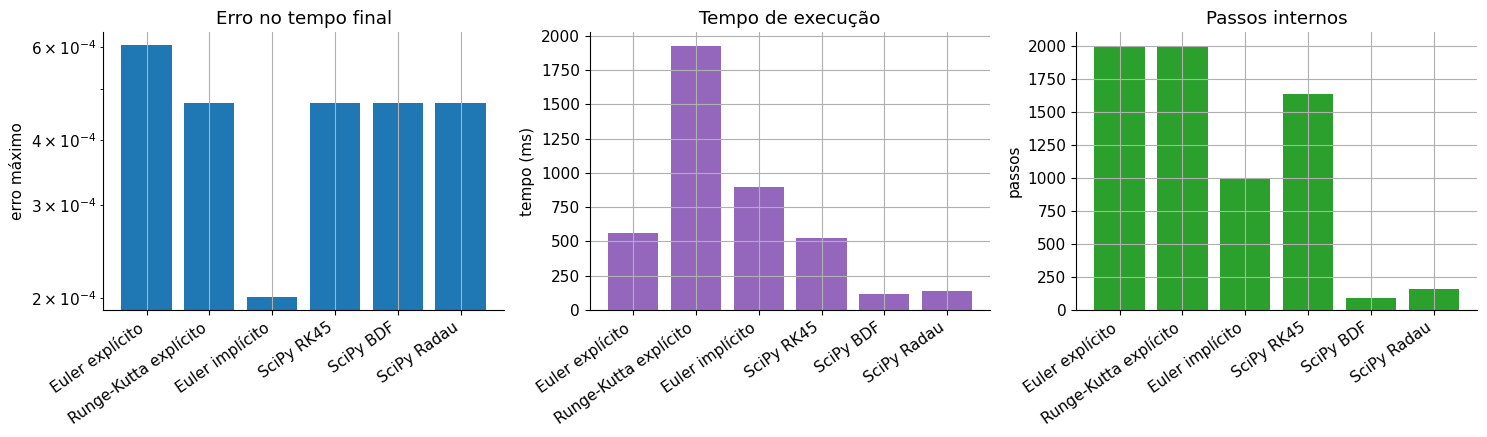

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
method_positions = np.arange(len(solver_comparison_1d))

axes[0].bar(method_positions, solver_comparison_1d["erro máximo"], color="tab:blue")
axes[0].set_yscale("log")
axes[0].set_ylabel("erro máximo")
axes[0].set_title("Erro no tempo final")

axes[1].bar(method_positions, solver_comparison_1d["tempo (ms)"], color="tab:purple")
axes[1].set_ylabel("tempo (ms)")
axes[1].set_title("Tempo de execução")

axes[2].bar(method_positions, solver_comparison_1d["passos"], color="tab:green")
axes[2].set_ylabel("passos")
axes[2].set_title("Passos internos")

for axis in axes:
    axis.set_xticks(method_positions)
    axis.set_xticklabels(solver_comparison_1d["método"], rotation=35, ha="right")

fig.tight_layout()
plt.show()

Os métodos explícitos precisam respeitar uma restrição de estabilidade ligada a $h^2$. Os métodos via `SciPy`, especialmente `BDF` e `Radau`, usam controle adaptativo e conseguem trabalhar com uma quantidade menor de passos internos.

O Euler implícito é estável para passos maiores que o Euler explícito, mas a implementação iterativa da `py-pde` ainda precisa resolver um problema não linear em cada passo. Mesmo em um exemplo linear, isso pode ter custo relevante.

## Bônus: Lotka-Volterra usando `py-pde`

Como bônus, vamos resolver um sistema puramente temporal usando a infraestrutura da `py-pde`.

O sistema de Lotka-Volterra é

$$
\begin{aligned}
x'(t)&=\alpha x-\beta xy,\\
y'(t)&=\delta xy-\gamma y.
\end{aligned}
$$

Aqui não há variável espacial. Para usar a `py-pde`, representamos o estado como um `ScalarField` em uma grade fictícia com duas células:

* célula 0: população de presas;
* célula 1: população de predadores.

Não aplicamos operadores espaciais; a classe customizada apenas calcula as taxas temporais das duas componentes.

In [14]:
class LotkaVolterraPDE(pde.PDEBase):
    def __init__(self, alpha=1.1, beta=0.4, delta=0.1, gamma=0.4):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.gamma = gamma

    def evolution_rate(self, state, time=0):
        prey = state.data[0]
        predators = state.data[1]

        rate = np.empty_like(state.data)
        rate[0] = self.alpha * prey - self.beta * prey * predators
        rate[1] = self.delta * prey * predators - self.gamma * predators

        return pde.ScalarField(state.grid, data=rate, label="taxa")

    def invariant(self, prey, predators):
        return (
            self.delta * prey
            - self.gamma * np.log(prey)
            + self.beta * predators
            - self.alpha * np.log(predators)
        )


lotka_volterra = LotkaVolterraPDE()
lv_grid = pde.UnitGrid([2], periodic=True)
lv_initial_state = pde.ScalarField(
    lv_grid,
    data=np.array([10.0, 5.0]),
    label="Lotka-Volterra",
)

pd.DataFrame(
    {
        "parâmetro": [
            "alpha",
            "beta",
            "delta",
            "gamma",
            "presas iniciais",
            "predadores iniciais",
        ],
        "valor": [
            lotka_volterra.alpha,
            lotka_volterra.beta,
            lotka_volterra.delta,
            lotka_volterra.gamma,
            lv_initial_state.data[0],
            lv_initial_state.data[1],
        ],
    }
)

,parâmetro,valor
0,alpha,1.1
1,beta,0.4
2,delta,0.1
3,gamma,0.4
4,presas iniciais,10.0
5,predadores iniciais,5.0


In [15]:
def run_lotka_volterra_solver(label, solver, time_step, final_time=30.0):
    storage = pde.MemoryStorage()
    controller = pde.Controller(
        solver,
        t_range=final_time,
        tracker=storage.tracker(0.05),
    )

    tic = perf_counter()
    controller.run(lv_initial_state, dt=time_step)
    elapsed_ms = 1e3 * (perf_counter() - tic)

    times = np.array(list(storage.times))
    trajectory = np.array([field.data for _, field in storage.items()])
    prey = trajectory[:, 0]
    predators = trajectory[:, 1]
    invariant = lotka_volterra.invariant(prey, predators)

    return {
        "label": label,
        "times": times,
        "prey": prey,
        "predators": predators,
        "invariant": invariant,
        "elapsed_ms": elapsed_ms,
        "steps": controller.diagnostics["solver"].get("steps", np.nan),
    }


lv_solutions = [
    run_lotka_volterra_solver(
        "Euler explícito",
        ExplicitSolver(lotka_volterra, scheme="euler", backend="numpy"),
        0.005,
    ),
    run_lotka_volterra_solver(
        "Runge-Kutta explícito",
        ExplicitSolver(lotka_volterra, scheme="runge-kutta", backend="numpy"),
        0.02,
    ),
    run_lotka_volterra_solver(
        "Euler implícito",
        ImplicitSolver(lotka_volterra, backend="numpy", maxiter=100, maxerror=1e-8),
        0.005,
    ),
    run_lotka_volterra_solver(
        "SciPy DOP853",
        ScipySolver(
            lotka_volterra,
            backend="numpy",
            method="DOP853",
            rtol=1e-10,
            atol=1e-12,
        ),
        0.1,
    ),
]

pd.DataFrame(
    {
        "método": [item["label"] for item in lv_solutions],
        "tempo (ms)": [item["elapsed_ms"] for item in lv_solutions],
        "passos": [item["steps"] for item in lv_solutions],
        "desvio máximo do invariante": [
            np.max(np.abs(item["invariant"] - item["invariant"][0]))
            for item in lv_solutions
        ],
    }
)

,método,tempo (ms),passos,desvio máximo do invariante
0,Euler explícito,264.031849,6000,2.844697e-02
1,Runge-Kutta explícito,244.491429,1501,3.558409e-09
2,Euler implícito,920.611608,6000,2.692336e-02
3,SciPy DOP853,824.466855,9600,1.110223e-15


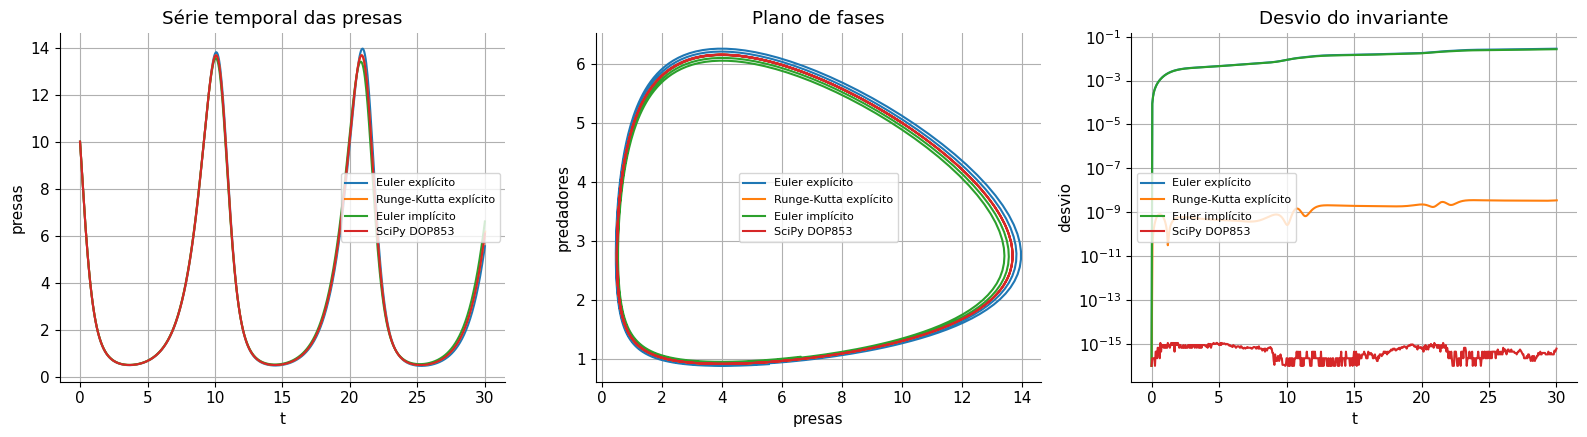

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for solution in lv_solutions:
    axes[0].plot(solution["times"], solution["prey"], label=solution["label"])
    axes[1].plot(solution["prey"], solution["predators"], label=solution["label"])
    axes[2].semilogy(
        solution["times"],
        np.maximum(np.abs(solution["invariant"] - solution["invariant"][0]), 1e-16),
        label=solution["label"],
    )

axes[0].set_xlabel("t")
axes[0].set_ylabel("presas")
axes[0].set_title("Série temporal das presas")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("presas")
axes[1].set_ylabel("predadores")
axes[1].set_title("Plano de fases")
axes[1].legend(fontsize=8)

axes[2].set_xlabel("t")
axes[2].set_ylabel("desvio")
axes[2].set_title("Desvio do invariante")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

Esse bônus mostra que a `py-pde` também pode integrar sistemas sem derivadas espaciais, desde que o estado seja representado como um campo. Para Lotka-Volterra, a comparação deixa claro algo que já apareceu nas aulas de ODE: métodos de baixa ordem podem distorcer a geometria das órbitas e o invariante do sistema, enquanto métodos de ordem maior preservam melhor a trajetória no plano de fases.